In [ ]:
!pip install pandas

In [25]:
import pandas as pd
import numpy as np
import os

base_dir = r'../data/specimen_data'  # folder containing multiple specimens_export_YYYYMMDD_HHMMSS subfolders

# find all subdirectories in base_dir
data_dirs = [os.path.join(base_dir, d) for d in os.listdir(base_dir)
             if os.path.isdir(os.path.join(base_dir, d))]

# filenames we expect in each subfolder
files_map = {
    'specimens': 'specimens.csv',
    'tensile': 'tensile_specimens.csv',
    'polish': 'polish_specimens.csv',
    'notch': 'notch_specimens.csv'
}

# collectors
specimens_list = []
tensile_list = []
polish_list = []
notch_list = []

for d in data_dirs:
    for key, fname in files_map.items():
        path = os.path.join(d, fname)
        if os.path.exists(path):
            try:
                df = pd.read_csv(path, sep=';')
            except Exception as e:
                print(f"Failed to read {path}: {e}")
                continue
            # add a source column indicating the file the row came from
            df['source'] = path
            if key == 'specimens':
                specimens_list.append(df)
            elif key == 'tensile':
                tensile_list.append(df)
            elif key == 'polish':
                polish_list.append(df)
            elif key == 'notch':
                notch_list.append(df)
        else:
            # optional: comment out if too noisy
            print(f"Not found: {path}")

# concatenate (if none found, create empty DataFrame)
specimens_df = pd.concat(specimens_list, ignore_index=True) if specimens_list else pd.DataFrame()
tensile_df = pd.concat(tensile_list, ignore_index=True) if tensile_list else pd.DataFrame()
polish_df = pd.concat(polish_list, ignore_index=True) if polish_list else pd.DataFrame()
notch_df = pd.concat(notch_list, ignore_index=True) if notch_list else pd.DataFrame()

print("Loaded:")
print(f"  specimens: {len(specimens_df)} rows")
print(f"  tensile:   {len(tensile_df)} rows")
print(f"  polish:    {len(polish_df)} rows")
print(f"  notch:     {len(notch_df)} rows")


Loaded:
  specimens: 12185 rows
  tensile:   8115 rows
  polish:    35465 rows
  notch:     2330 rows


In [46]:
polish_df['has_images']

0        False
1        False
2        False
3        False
4        False
         ...  
35460    False
35461    False
35462    False
35463    False
35464    False
Name: has_images, Length: 35465, dtype: bool

In [28]:
def extract_filename(url_string):
    """
    Extract the last filename from a URL string that may contain multiple paths separated by semicolons
    Example: "/documents/generic-form/.../RE-C015-S9_9bf94606_.bmp;documents/generic-form/.../RE-C015-S9.bmp" 
    Returns: "RE-C015-S9.bmp"
    """
    if pd.isna(url_string) or url_string == '':
        return url_string
    
    # Split by semicolon and take the last part
    parts = str(url_string).split(';')
    last_part = parts[-1]
    
    # Extract just the filename (everything after the last /)
    filename = last_part.split('/')[-1]
    
    return filename

In [21]:
import cv2
import numpy as np

def analyze_porosity(img_path, png_legend_ratio=1/45, kernel_ratio=1/200, 
                    bmp_legend_height=0.08, bmp_legend_height_value=200,
                    bmp_legend_width=0.4, bmp_legend_width_value=3000):
    """
    Analyze porosity from microscopy images
    
    Parameters:
    - img_path: path to the image file
    - png_legend_ratio: ratio for cropping PNG legend (default 1/45)
    - kernel_ratio: ratio for morphological kernel size (default 1/200)
    - bmp_legend_height: ratio for BMP legend height cropping (default 0.08)
    - bmp_legend_height_value: absolute value for BMP legend height (default 200)
    - bmp_legend_width: ratio for BMP legend width cropping (default 0.4)
    - bmp_legend_width_value: absolute value for BMP legend width (default 3000)
    """
    
    # Read the image
    og_img = cv2.imread(img_path)
    
    # Convert to grayscale
    img = cv2.cvtColor(og_img, cv2.COLOR_BGR2GRAY)
    
    # Crop the legend based on file type
    if img_path.endswith('.jpg') or img_path.endswith('.png'):
        legend_crop_value = int(img.shape[0] * png_legend_ratio)
        cropped_img = img[legend_crop_value:, :]  # crop the legend
    elif img_path.endswith('.bmp'):
        height_crop = int(img.shape[0] * bmp_legend_height) if img.shape[0] < 5000 else bmp_legend_height_value
        width_crop = int(img.shape[1] * bmp_legend_width) if img.shape[1] < 2000 else bmp_legend_width_value
        img[height_crop:, width_crop:] = 0  # Replace the bottom right corner with a black square
        cropped_img = img
    else:
        cropped_img = img
    
    # Apply thresholding
    _, binary_img = cv2.threshold(cropped_img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    # Fill the holes using morphological operations
    kernel_size = int(img.shape[0] * kernel_ratio)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Calculate the whole area counts
    whole_area_counts = np.count_nonzero(mask == 255)
    
    # Create an inverse of the binary image
    inverse_binary = cv2.bitwise_not(binary_img)
    
    # Combine the inverse binary image with the mask
    combined_mask = cv2.bitwise_and(inverse_binary, mask)
    
    # Calculate the pore area counts
    pore_area_counts = np.count_nonzero(combined_mask == 255)
    
    # Calculate porosity
    porosity = pore_area_counts * 100 / whole_area_counts if whole_area_counts > 0 else 0
    
    return porosity

In [45]:
polish_df.dropna(subset=['porosity'])[['specimens_key', 'porosity', 'name', 'porosity', 'porosity_1', 'porosity_2', 'porosity_3']]

,specimens_key,porosity,name,porosity,porosity_1,porosity_2,porosity_3
40,0970fb920717be61e5ee2336464ed047,0.29,NaN,0.29,0.29,NaN,NaN
82,46e21f698c2f5b0f19f3d0ba03220608,1.68,NaN,1.68,1.68,NaN,NaN
123,4316738581f76c3fa9f71c82b82949d3,0.03,NaN,0.03,0.03,NaN,NaN
162,629b060e5d12e7d4e39dd7a3636ac9d6,9.76,NaN,9.76,9.76,NaN,NaN
163,12d05346f50ed7374c2fbfd04670f8e7,0.09,NaN,0.09,0.09,NaN,NaN
...,...,...,...,...,...,...,...
35405,026dd7028267420ff2a9acfe6d58c2f3,0.30,RE-A012,0.30,0.30,NaN,NaN
35407,3917983e886fdb681a444ddaf2317d69,0.12,NaN,0.12,0.12,NaN,NaN
35408,402ddddc3f7187d00ff48368ecc03102,0.02,NaN,0.02,0.02,NaN,NaN
35409,026dd7028267420ff2a9acfe6d58c2f3,0.12,RE-A012,0.12,0.12,NaN,NaN


In [62]:
df = polish_df.dropna(subset=['porosity', 'name'])[['specimens_key', 'source', 'porosity', 'name', 'number', 'polish_img_url_1', 'polish_img_url_2', 'polish_img_url_3']]
df['filename'] = df['polish_img_url_1'].apply(extract_filename)

In [68]:
test = polish_df[polish_df['has_images'] == True].dropna(subset=['porosity'])[['specimens_key', 'source','name', 'number','has_images', 'polish_img_url_1', 'polish_img_url_2', 'polish_img_url_3', 'porosity']]
test['filename'] = test['polish_img_url_1'].apply(extract_filename)

In [69]:
df = test

In [70]:
df

,specimens_key,source,name,number,has_images,polish_img_url_1,polish_img_url_2,polish_img_url_3,porosity,filename
40,0970fb920717be61e5ee2336464ed047,../data/specimen_data\specimens_export_2025102...,NaN,S009,True,/documents/generic-form/00ca4e0ac00134fbb953fb...,NaN,NaN,0.29,RE-C015-S9.bmp
82,46e21f698c2f5b0f19f3d0ba03220608,../data/specimen_data\specimens_export_2025102...,NaN,S001,True,/documents/generic-form/02ee802c66119b4318fff1...,NaN,NaN,1.68,RE-B154-S001.bmp
123,4316738581f76c3fa9f71c82b82949d3,../data/specimen_data\specimens_export_2025102...,NaN,S006,True,/documents/generic-form/047e75607093a187c59e64...,NaN,NaN,0.03,RE-B541-S6_1.jpg
162,629b060e5d12e7d4e39dd7a3636ac9d6,../data/specimen_data\specimens_export_2025102...,NaN,S005,True,/documents/generic-form/062ffeec156cb71dab39e2...,NaN,NaN,9.76,RE-B151_S005.bmp
163,12d05346f50ed7374c2fbfd04670f8e7,../data/specimen_data\specimens_export_2025102...,NaN,S001,True,/documents/generic-form/05c77a9a600053dbb76094...,NaN,NaN,0.09,RE-B447-S01.bmp
...,...,...,...,...,...,...,...,...,...,...
35405,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,RE-A012,S003,True,/documents/generic-form/71e28ba090533154cfdee0...,NaN,NaN,0.30,RE-A012-S3.bmp
35407,3917983e886fdb681a444ddaf2317d69,../data/specimen_data\specimens_export_2025102...,NaN,S001,True,/documents/generic-form/764aebf4d7c98e67b93bcb...,NaN,NaN,0.12,RE-B760_1.jpg
35408,402ddddc3f7187d00ff48368ecc03102,../data/specimen_data\specimens_export_2025102...,NaN,S004,True,/documents/generic-form/f1ab72d57b45da01b61ae1...,NaN,NaN,0.02,RE-B797_4.jpg
35409,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,RE-A012,S007,True,/documents/generic-form/5ed3a760cd9c5196ad8df9...,NaN,NaN,0.12,RE-A012-S7.bmp


In [71]:
import os
import matplotlib.pyplot as plt

# Build image_path from each row's 'source' (assumed to point to the export folder)
def build_image_path(row):
    src = row.get('source')
    fn = row.get('filename')
    if pd.isna(fn) or pd.isna(src):
        return None
    src_path = os.path.normpath(str(src))
    # if source points to a file rather than a directory, take its dirname
    if os.path.isfile(src_path):
        src_path = os.path.dirname(src_path)
    # avoid duplicating 'images' if source already ends with it
    if os.path.basename(src_path).lower() == 'images':
        base = src_path
    else:
        base = os.path.join(src_path, 'images')
    return os.path.join(base, str(fn))

df['image_path'] = df.apply(build_image_path, axis=1)

# Function to safely calculate porosity
def safe_analyze_porosity(img_path):
    """
    Safely analyze porosity with error handling
    """
    try:
        if pd.isna(img_path) or not os.path.exists(img_path):
            return None
        return analyze_porosity(img_path)
    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")
        return None

# Calculate porosity for each image
print("Calculating porosity for each image...")
df['calculated_porosity'] = df['image_path'].apply(safe_analyze_porosity)

# Create comparison DataFrame
comparison_df = df[['name', 'number', 'porosity', 'calculated_porosity', 'filename']].copy()
comparison_df = comparison_df.dropna(subset=['calculated_porosity'])  # Remove failed calculations

# Add difference column
comparison_df['difference'] = comparison_df['calculated_porosity'] - comparison_df['porosity']
comparison_df['abs_difference'] = abs(comparison_df['difference'])
comparison_df['percent_difference'] = (comparison_df['difference'] / comparison_df['porosity'] * 100).round(2)

# Display results
print(f"\nSuccessfully calculated porosity for {len(comparison_df)} images out of {len(df)} total")
print(f"\nComparison Results:")
print("="*80)
print(comparison_df.round(4))

# Summary statistics
print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}")
print(f"Mean given porosity: {comparison_df['porosity'].mean():.4f}")
print(f"Mean calculated porosity: {comparison_df['calculated_porosity'].mean():.4f}")
print(f"Mean absolute difference: {comparison_df['abs_difference'].mean():.4f}")
print(f"Standard deviation of differences: {comparison_df['difference'].std():.4f}")
print(f"Correlation coefficient: {comparison_df['porosity'].corr(comparison_df['calculated_porosity']):.4f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter plot: Given vs Calculated
axes[0,0].scatter(comparison_df['porosity'], comparison_df['calculated_porosity'], alpha=0.6)
axes[0,0].plot([comparison_df['porosity'].min(), comparison_df['porosity'].max()], 
               [comparison_df['porosity'].min(), comparison_df['porosity'].max()], 'r--', label='Perfect correlation')
axes[0,0].set_xlabel('Given Porosity')
axes[0,0].set_ylabel('Calculated Porosity')
axes[0,0].set_title('Given vs Calculated Porosity')
axes[0,0].legend()
axes[0,0].grid(True)

# 2. Histogram of differences
axes[0,1].hist(comparison_df['difference'], bins=20, alpha=0.7, edgecolor='black')
axes[0,1].set_xlabel('Difference (Calculated - Given)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Differences')
axes[0,1].grid(True)

# 3. Box plot of both porosity values
axes[1,0].boxplot([comparison_df['porosity'], comparison_df['calculated_porosity']], 
                  labels=['Given', 'Calculated'])
axes[1,0].set_ylabel('Porosity Value')
axes[1,0].set_title('Box Plot Comparison')
axes[1,0].grid(True)

# 4. Absolute differences by specimen
axes[1,1].bar(range(len(comparison_df)), comparison_df['abs_difference'])
axes[1,1].set_xlabel('Specimen Index')
axes[1,1].set_ylabel('Absolute Difference')
axes[1,1].set_title('Absolute Differences by Specimen')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Detailed analysis for specimens with large differences
large_diff_threshold = comparison_df['abs_difference'].quantile(0.8)  # Top 20% of differences
large_differences = comparison_df[comparison_df['abs_difference'] > large_diff_threshold]

if len(large_differences) > 0:
    print(f"\n{'='*80}")
    print(f"SPECIMENS WITH LARGE DIFFERENCES (>{large_diff_threshold:.4f})")
    print(f"{'='*80}")
    print(large_differences[['name', 'porosity', 'calculated_porosity', 'difference', 'percent_difference']].round(4))

# Check which images exist vs which don't
missing_images = df[df['image_path'].apply(lambda x: not os.path.exists(x) if pd.notna(x) else True)]
if len(missing_images) > 0:
    print(f"\n{'='*80}")
    print(f"MISSING IMAGE FILES ({len(missing_images)} files)")
    print(f"{'='*80}")
    for idx, row in missing_images.iterrows():
        print(f"Missing: {row['filename']} (Specimen: {row['name']})")

# Final summary
print(f"\n{'='*80}")
print("FINAL SUMMARY")
print(f"{'='*80}")
print(f"Total specimens with porosity data: {len(df)}")
print(f"Images found: {len(df[df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)])}")
print(f"Successful porosity calculations: {len(comparison_df)}")
print(f"Failed calculations: {len(df) - len(comparison_df)}")
print(f"Average absolute difference: {comparison_df['abs_difference'].mean():.4f}")
print(f"Median absolute difference: {comparison_df['abs_difference'].median():.4f}")
print(f"Maximum difference: {comparison_df['abs_difference'].max():.4f}")
print(f"Minimum difference: {comparison_df['abs_difference'].min():.4f}")

Calculating porosity for each image...


KeyboardInterrupt: 

Calculating porosity for each image...
Saved full dataset to: porosity_analysis_full_20260225_021624.csv
Saved comparison data to: porosity_comparison_20260225_021624.csv

Successfully calculated porosity for 722 images out of 3505 total

Comparison Results:
          name number  porosity  calculated_porosity          filename  \
40         NaN   S009      0.29               0.3362    RE-C015-S9.bmp   
82         NaN   S001      1.68               1.7581  RE-B154-S001.bmp   
123        NaN   S006      0.03               0.2005  RE-B541-S6_1.jpg   
162        NaN   S005      9.76               6.7580  RE-B151_S005.bmp   
163        NaN   S001      0.09               0.2011   RE-B447-S01.bmp   
...        ...    ...       ...                  ...               ...   
35405  RE-A012   S003      0.30               0.4129    RE-A012-S3.bmp   
35407      NaN   S001      0.12               0.2416     RE-B760_1.jpg   
35408      NaN   S004      0.02               0.1341     RE-B797_4.jpg   
3

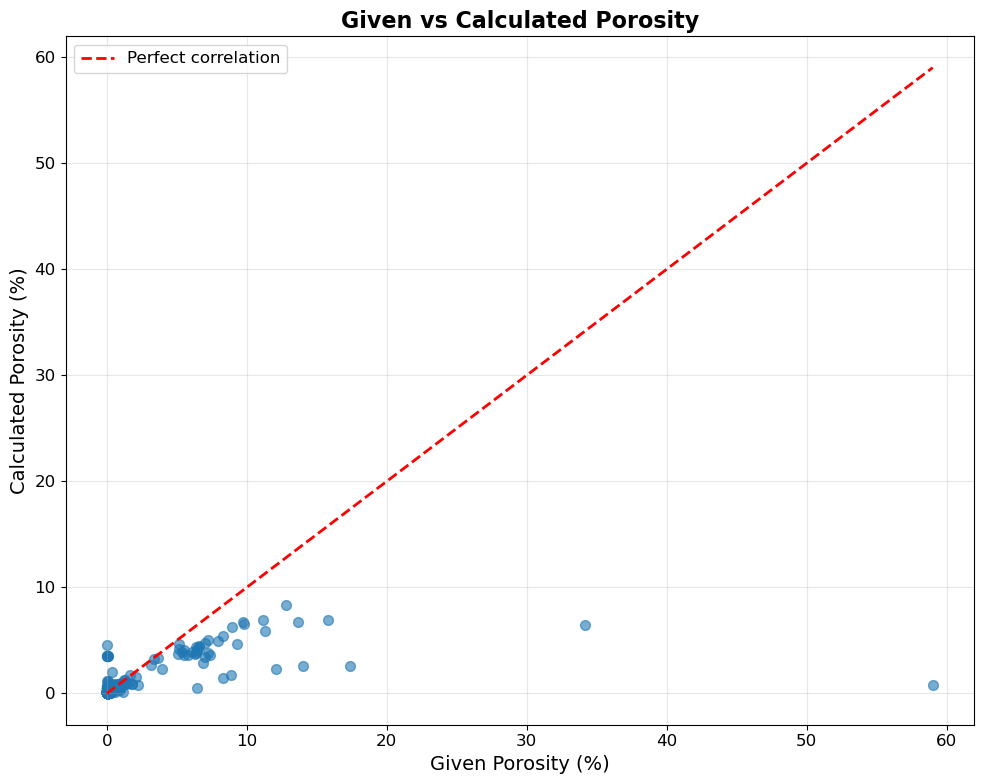

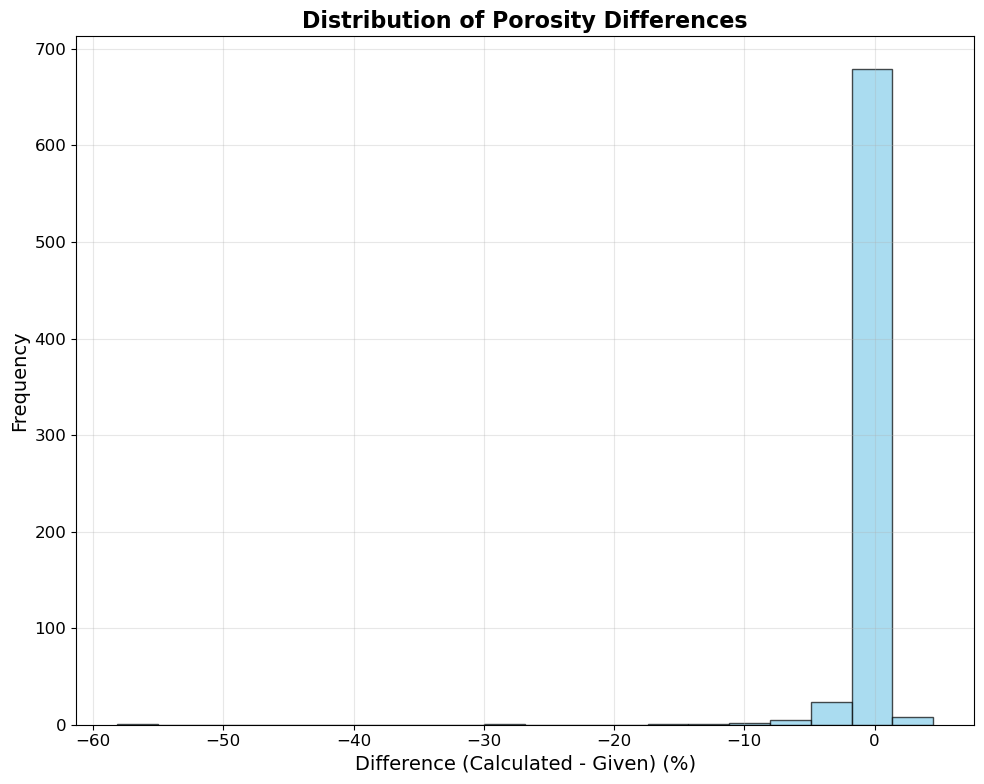

C:\Users\perrydebussy\AppData\Local\Temp\ipykernel_29012\1771719594.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['Given', 'Calculated'], patch_artist=True)


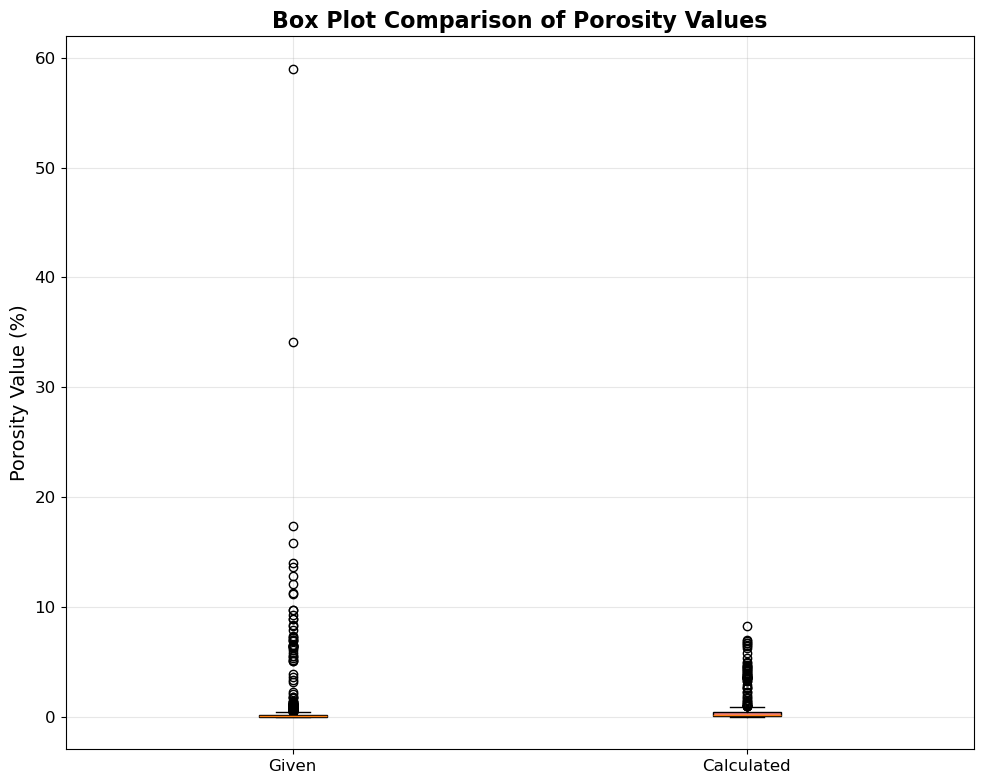

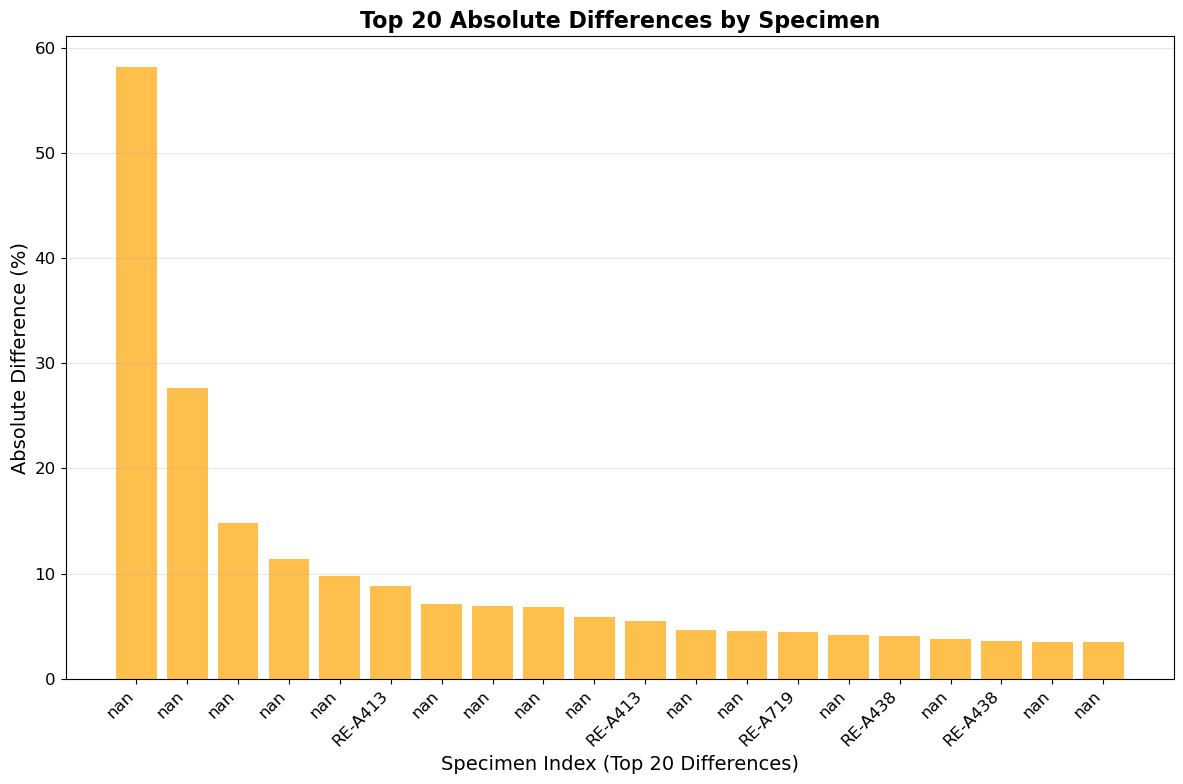

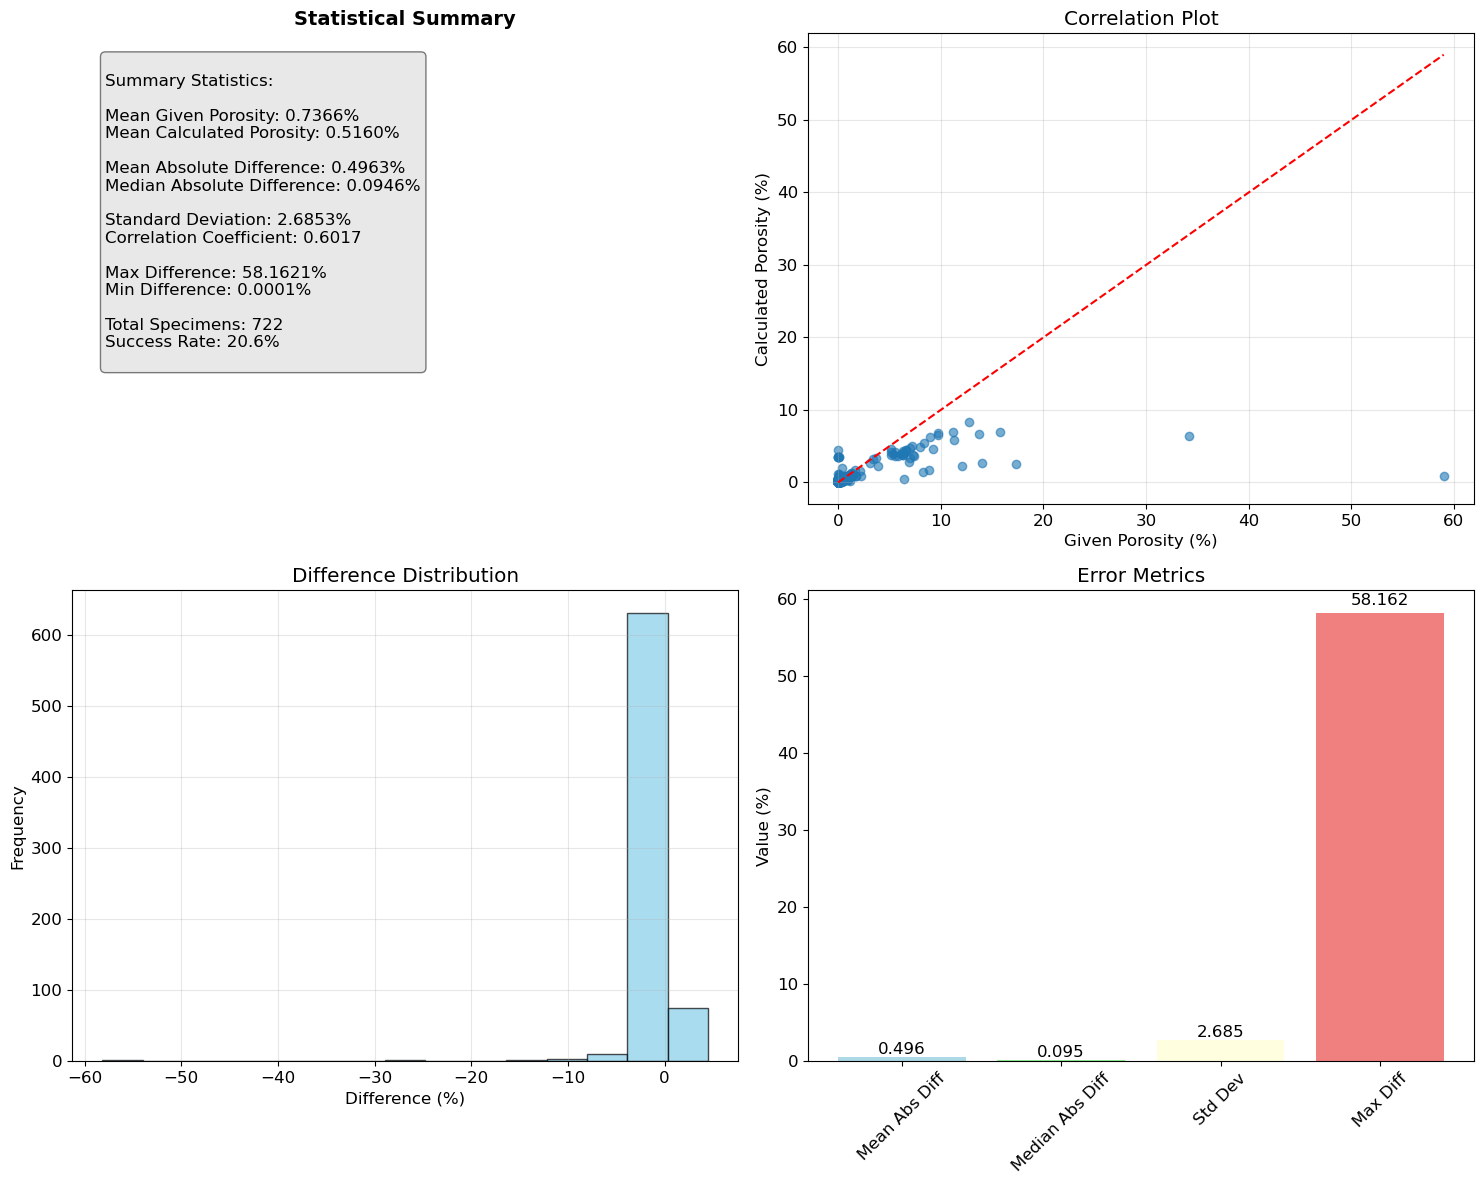


SPECIMENS WITH LARGE DIFFERENCES (>0.2966)
          name  porosity  calculated_porosity  difference  percent_difference
162        NaN     9.760               6.7580     -3.0020              -30.76
330        NaN     5.540               4.1307     -1.4093              -25.44
666        NaN     0.060               0.4806      0.4206              701.04
1085       NaN     3.670               3.3081     -0.3619               -9.86
1342       NaN     0.270               0.5887      0.3187              118.05
...        ...       ...                  ...         ...                 ...
35306      NaN    11.150               6.9598     -4.1902              -37.58
35324      NaN     0.030               0.4544      0.4244             1414.51
35398  RE-A012     0.065               0.3734      0.3084              474.51
35401  RE-A012     0.765               0.4306     -0.3344              -43.71
35410  RE-A012     0.080               0.4043      0.3243              405.40

[145 rows x 5 colum

In [72]:
import os
import matplotlib.pyplot as plt
from datetime import datetime

# Build image_path from each row's 'source' (assumed to point to the export folder)
def build_image_path(row):
    src = row.get('source')
    fn = row.get('filename')
    if pd.isna(fn) or pd.isna(src):
        return None
    src_path = os.path.normpath(str(src))
    # if source points to a file rather than a directory, take its dirname
    if os.path.isfile(src_path):
        src_path = os.path.dirname(src_path)
    # avoid duplicating 'images' if source already ends with it
    if os.path.basename(src_path).lower() == 'images':
        base = src_path
    else:
        base = os.path.join(src_path, 'images')
    return os.path.join(base, str(fn))

df['image_path'] = df.apply(build_image_path, axis=1)

# Function to safely calculate porosity
def safe_analyze_porosity(img_path):
    """
    Safely analyze porosity with error handling
    """
    try:
        if pd.isna(img_path) or not os.path.exists(img_path):
            return None
        return analyze_porosity(img_path)
    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")
        return None

# Calculate porosity for each image
print("Calculating porosity for each image...")
df['calculated_porosity'] = df['image_path'].apply(safe_analyze_porosity)

# Create comparison DataFrame
comparison_df = df[['name', 'number', 'porosity', 'calculated_porosity', 'filename']].copy()
comparison_df = comparison_df.dropna(subset=['calculated_porosity'])  # Remove failed calculations

# Add difference column
comparison_df['difference'] = comparison_df['calculated_porosity'] - comparison_df['porosity']
comparison_df['abs_difference'] = abs(comparison_df['difference'])
comparison_df['percent_difference'] = (comparison_df['difference'] / comparison_df['porosity'] * 100).round(2)

# Save DataFrames to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
df.to_csv(f'porosity_analysis_full_{timestamp}.csv', index=False)
comparison_df.to_csv(f'porosity_comparison_{timestamp}.csv', index=False)

print(f"Saved full dataset to: porosity_analysis_full_{timestamp}.csv")
print(f"Saved comparison data to: porosity_comparison_{timestamp}.csv")

# Display results
print(f"\nSuccessfully calculated porosity for {len(comparison_df)} images out of {len(df)} total")
print(f"\nComparison Results:")
print("="*80)
print(comparison_df.round(4))

# Calculate statistics
stats = {
    'mean_given': comparison_df['porosity'].mean(),
    'mean_calculated': comparison_df['calculated_porosity'].mean(),
    'mean_abs_diff': comparison_df['abs_difference'].mean(),
    'std_diff': comparison_df['difference'].std(),
    'correlation': comparison_df['porosity'].corr(comparison_df['calculated_porosity']),
    'median_abs_diff': comparison_df['abs_difference'].median(),
    'max_diff': comparison_df['abs_difference'].max(),
    'min_diff': comparison_df['abs_difference'].min()
}

# Summary statistics
print(f"\n{'='*80}")
print("SUMMARY STATISTICS")
print(f"{'='*80}")
print(f"Mean given porosity: {stats['mean_given']:.4f}")
print(f"Mean calculated porosity: {stats['mean_calculated']:.4f}")
print(f"Mean absolute difference: {stats['mean_abs_diff']:.4f}")
print(f"Standard deviation of differences: {stats['std_diff']:.4f}")
print(f"Correlation coefficient: {stats['correlation']:.4f}")

# Create separate visualizations for presentation
plt.rcParams.update({'font.size': 12})  # Increase font size for presentation

# 1. Scatter plot: Given vs Calculated
plt.figure(figsize=(10, 8))
plt.scatter(comparison_df['porosity'], comparison_df['calculated_porosity'], alpha=0.6, s=50)
plt.plot([comparison_df['porosity'].min(), comparison_df['porosity'].max()], 
         [comparison_df['porosity'].min(), comparison_df['porosity'].max()], 'r--', linewidth=2, label='Perfect correlation')
plt.xlabel('Given Porosity (%)', fontsize=14)
plt.ylabel('Calculated Porosity (%)', fontsize=14)
plt.title('Given vs Calculated Porosity', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'scatter_plot_porosity_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Histogram of differences
plt.figure(figsize=(10, 8))
plt.hist(comparison_df['difference'], bins=20, alpha=0.7, edgecolor='black', color='skyblue')
plt.xlabel('Difference (Calculated - Given) (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Porosity Differences', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'histogram_differences_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Box plot of both porosity values
plt.figure(figsize=(10, 8))
box_data = [comparison_df['porosity'], comparison_df['calculated_porosity']]
bp = plt.boxplot(box_data, labels=['Given', 'Calculated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
plt.ylabel('Porosity Value (%)', fontsize=14)
plt.title('Box Plot Comparison of Porosity Values', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'boxplot_comparison_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Absolute differences by specimen (showing top 20 for clarity)
plt.figure(figsize=(12, 8))
top_20_diff = comparison_df.nlargest(20, 'abs_difference')
plt.bar(range(len(top_20_diff)), top_20_diff['abs_difference'], color='orange', alpha=0.7)
plt.xlabel('Specimen Index (Top 20 Differences)', fontsize=14)
plt.ylabel('Absolute Difference (%)', fontsize=14)
plt.title('Top 20 Absolute Differences by Specimen', fontsize=16, fontweight='bold')
plt.xticks(range(len(top_20_diff)), top_20_diff['name'], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'top_differences_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Statistics summary plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Statistics text
stats_text = f"""
Summary Statistics:

Mean Given Porosity: {stats['mean_given']:.4f}%
Mean Calculated Porosity: {stats['mean_calculated']:.4f}%

Mean Absolute Difference: {stats['mean_abs_diff']:.4f}%
Median Absolute Difference: {stats['median_abs_diff']:.4f}%

Standard Deviation: {stats['std_diff']:.4f}%
Correlation Coefficient: {stats['correlation']:.4f}

Max Difference: {stats['max_diff']:.4f}%
Min Difference: {stats['min_diff']:.4f}%

Total Specimens: {len(comparison_df)}
Success Rate: {len(comparison_df)/len(df)*100:.1f}%
"""

ax1.text(0.05, 0.95, stats_text, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
ax1.set_title('Statistical Summary', fontsize=14, fontweight='bold')
ax1.axis('off')

# Correlation plot
ax2.scatter(comparison_df['porosity'], comparison_df['calculated_porosity'], alpha=0.6)
ax2.plot([comparison_df['porosity'].min(), comparison_df['porosity'].max()], 
         [comparison_df['porosity'].min(), comparison_df['porosity'].max()], 'r--')
ax2.set_xlabel('Given Porosity (%)')
ax2.set_ylabel('Calculated Porosity (%)')
ax2.set_title('Correlation Plot')
ax2.grid(True, alpha=0.3)

# Difference distribution
ax3.hist(comparison_df['difference'], bins=15, alpha=0.7, edgecolor='black', color='skyblue')
ax3.set_xlabel('Difference (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Difference Distribution')
ax3.grid(True, alpha=0.3)

# Error metrics
metrics = ['Mean Abs Diff', 'Median Abs Diff', 'Std Dev', 'Max Diff']
values = [stats['mean_abs_diff'], stats['median_abs_diff'], stats['std_diff'], stats['max_diff']]
bars = ax4.bar(metrics, values, color=['lightblue', 'lightgreen', 'lightyellow', 'lightcoral'])
ax4.set_ylabel('Value (%)')
ax4.set_title('Error Metrics')
ax4.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'statistics_summary_{timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed analysis for specimens with large differences
large_diff_threshold = comparison_df['abs_difference'].quantile(0.8)  # Top 20% of differences
large_differences = comparison_df[comparison_df['abs_difference'] > large_diff_threshold]

if len(large_differences) > 0:
    print(f"\n{'='*80}")
    print(f"SPECIMENS WITH LARGE DIFFERENCES (>{large_diff_threshold:.4f})")
    print(f"{'='*80}")
    print(large_differences[['name', 'porosity', 'calculated_porosity', 'difference', 'percent_difference']].round(4))
    
    # Save large differences to separate CSV
    large_differences.to_csv(f'large_differences_{timestamp}.csv', index=False)
    print(f"Saved large differences to: large_differences_{timestamp}.csv")

# Check which images exist vs which don't
missing_images = df[df['image_path'].apply(lambda x: not os.path.exists(x) if pd.notna(x) else True)]
if len(missing_images) > 0:
    print(f"\n{'='*80}")
    print(f"MISSING IMAGE FILES ({len(missing_images)} files)")
    print(f"{'='*80}")
    for idx, row in missing_images.iterrows():
        print(f"Missing: {row['filename']} (Specimen: {row['name']})")
    
    # Save missing images info
    missing_images.to_csv(f'missing_images_{timestamp}.csv', index=False)
    print(f"Saved missing images info to: missing_images_{timestamp}.csv")

# Final summary
print(f"\n{'='*80}")
print("FINAL SUMMARY")
print(f"{'='*80}")
print(f"Total specimens with porosity data: {len(df)}")
print(f"Images found: {len(df[df['image_path'].apply(lambda x: os.path.exists(x) if pd.notna(x) else False)])}")
print(f"Successful porosity calculations: {len(comparison_df)}")
print(f"Failed calculations: {len(df) - len(comparison_df)}")
print(f"Average absolute difference: {stats['mean_abs_diff']:.4f}")
print(f"Median absolute difference: {stats['median_abs_diff']:.4f}")
print(f"Maximum difference: {stats['max_diff']:.4f}")
print(f"Minimum difference: {stats['min_diff']:.4f}")

print(f"\n{'='*80}")
print("FILES SAVED FOR PRESENTATION:")
print(f"{'='*80}")
print(f"1. scatter_plot_porosity_{timestamp}.png")
print(f"2. histogram_differences_{timestamp}.png") 
print(f"3. boxplot_comparison_{timestamp}.png")
print(f"4. top_differences_{timestamp}.png")
print(f"5. statistics_summary_{timestamp}.png")
print(f"6. porosity_analysis_full_{timestamp}.csv")
print(f"7. porosity_comparison_{timestamp}.csv")

In [41]:
df

,specimens_key,source,porosity,name,number,polish_img_url_1,polish_img_url_2,polish_img_url_3,filename,image_path,calculated_porosity
1553,5e5743e9df98d3fa9c5055571623373f,../data/specimen_data\specimens_export_2025102...,0.100,RE-A447,S004,/documents/generic-form/41cf627ca3a3037623a507...,NaN,NaN,RE-A447_S04.bmp,..\data\specimen_data\specimens_export_2025102...,0.068091
1592,5e5743e9df98d3fa9c5055571623373f,../data/specimen_data\specimens_export_2025102...,0.030,RE-A447,S011,/documents/generic-form/44cc7279f6a7c853e0c98d...,NaN,NaN,RE-A447_S11.bmp,..\data\specimen_data\specimens_export_2025102...,0.032288
1633,89b71c7159855927656727d0868f5c8e,../data/specimen_data\specimens_export_2025102...,0.040,RE-A207,S002,/documents/generic-form/461f80de333e4dd7763a2d...,NaN,NaN,RE-S-A207_2.bmp,..\data\specimen_data\specimens_export_2025102...,0.037609
1927,5e5743e9df98d3fa9c5055571623373f,../data/specimen_data\specimens_export_2025102...,0.020,RE-A447,S013,/documents/generic-form/53308c2cfb173ffaf92502...,NaN,NaN,RE-A447_S13.bmp,..\data\specimen_data\specimens_export_2025102...,0.062620
2010,97b67ee1ff9d9ce21e91e68182941648,../data/specimen_data\specimens_export_2025102...,0.040,RE-A071,S003,/documents/generic-form/570bae3b060ce6bc721b83...,NaN,NaN,RE-A071-3.bmp,..\data\specimen_data\specimens_export_2025102...,0.021781
...,...,...,...,...,...,...,...,...,...,...,...
35398,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,0.065,RE-A012,S005,/documents/generic-form/d25594ce8dbb70e5d9a758...,NaN,NaN,RE-A012-S5.bmp,..\data\specimen_data\specimens_export_2025102...,0.373433
35401,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,0.765,RE-A012,S002,/documents/generic-form/b4a3f1719f02a491dbd0f5...,NaN,NaN,RE-A012-S2.bmp,..\data\specimen_data\specimens_export_2025102...,0.430626
35405,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,0.300,RE-A012,S003,/documents/generic-form/71e28ba090533154cfdee0...,NaN,NaN,RE-A012-S3.bmp,..\data\specimen_data\specimens_export_2025102...,0.412906
35409,026dd7028267420ff2a9acfe6d58c2f3,../data/specimen_data\specimens_export_2025102...,0.120,RE-A012,S007,/documents/generic-form/5ed3a760cd9c5196ad8df9...,NaN,NaN,RE-A012-S7.bmp,..\data\specimen_data\specimens_export_2025102...,0.381160


In [74]:
comparison_df['name'] = comparison_df['filename'].apply(lambda x: x.rsplit('.', 1)[0] if pd.notna(x) else 'Unknown')

In [75]:
comparison_df

,name,number,porosity,calculated_porosity,filename,difference,abs_difference,percent_difference
40,RE-C015-S9,S009,0.29,0.336214,RE-C015-S9.bmp,0.046214,0.046214,15.94
82,RE-B154-S001,S001,1.68,1.758104,RE-B154-S001.bmp,0.078104,0.078104,4.65
123,RE-B541-S6_1,S006,0.03,0.200469,RE-B541-S6_1.jpg,0.170469,0.170469,568.23
162,RE-B151_S005,S005,9.76,6.757994,RE-B151_S005.bmp,-3.002006,3.002006,-30.76
163,RE-B447-S01,S001,0.09,0.201066,RE-B447-S01.bmp,0.111066,0.111066,123.41
...,...,...,...,...,...,...,...,...
35405,RE-A012-S3,S003,0.30,0.412906,RE-A012-S3.bmp,0.112906,0.112906,37.64
35407,RE-B760_1,S001,0.12,0.241552,RE-B760_1.jpg,0.121552,0.121552,101.29
35408,RE-B797_4,S004,0.02,0.134072,RE-B797_4.jpg,0.114072,0.114072,570.36
35409,RE-A012-S7,S007,0.12,0.381160,RE-A012-S7.bmp,0.261160,0.261160,217.63


Filtered data: 712 specimens in 0-10% porosity range


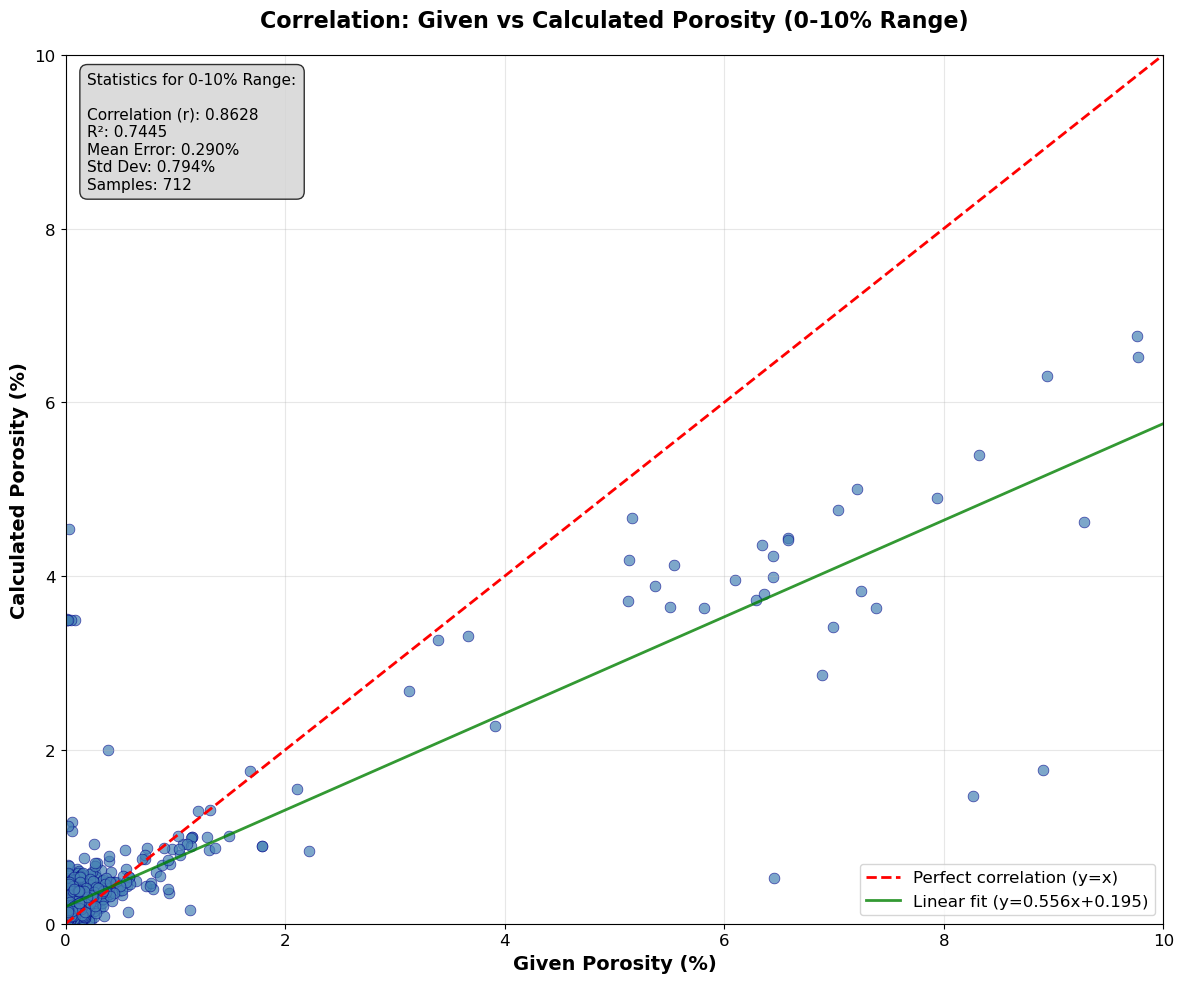


LOW POROSITY RANGE (0-10%) STATISTICS
Number of specimens: 712
Mean given porosity: 0.4642%
Mean calculated porosity: 0.4535%
Correlation coefficient (r): 0.8628
R-squared (r²): 0.7445
Mean absolute difference: 0.2902%
Median absolute difference: 0.0933%
Standard deviation of differences: 0.7940%
Maximum difference: 7.1365%
Minimum difference: 0.0001%

SPECIMENS IN 0-10% POROSITY RANGE
               name  porosity  calculated_porosity  difference  abs_difference
40       RE-C015-S9      0.29               0.3362      0.0462          0.0462
82     RE-B154-S001      1.68               1.7581      0.0781          0.0781
123    RE-B541-S6_1      0.03               0.2005      0.1705          0.1705
162    RE-B151_S005      9.76               6.7580     -3.0020          3.0020
163     RE-B447-S01      0.09               0.2011      0.1111          0.1111
...             ...       ...                  ...         ...             ...
35405    RE-A012-S3      0.30               0.4129      0

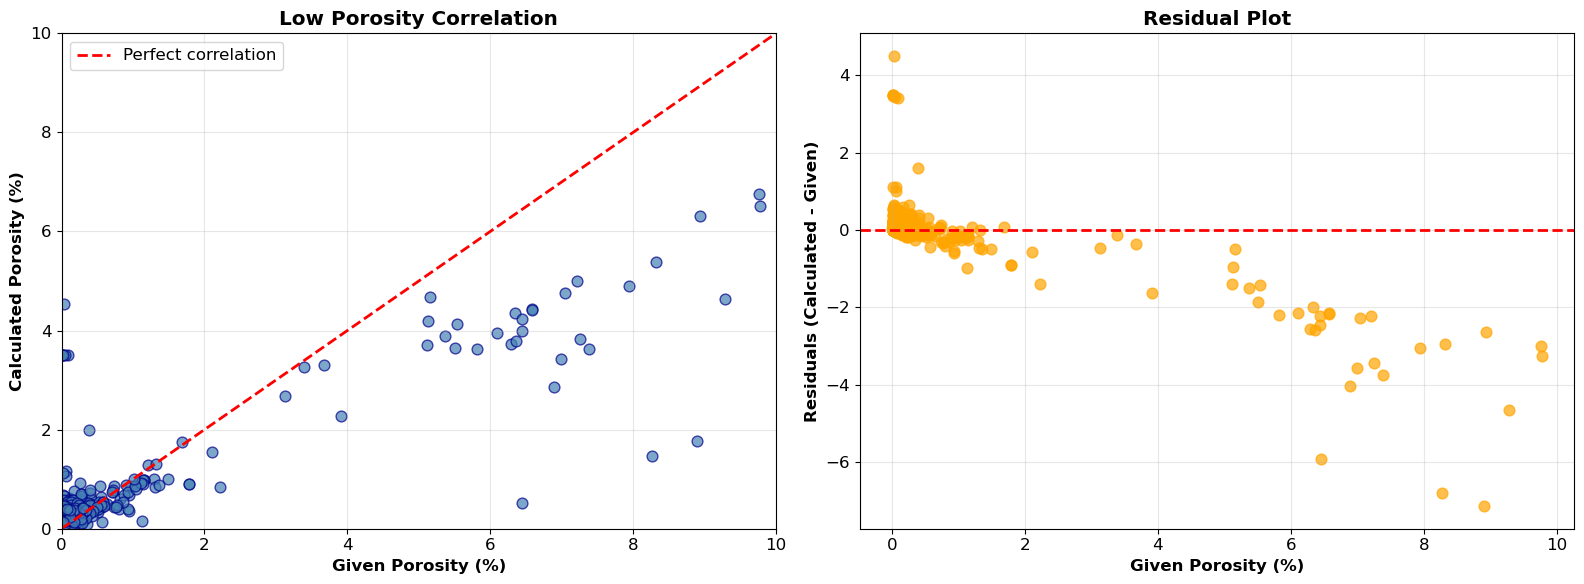

In [76]:
# Filter data for 0-10% porosity range
low_porosity_df = comparison_df[
    (comparison_df['porosity'] <= 10) & 
    (comparison_df['calculated_porosity'] <= 10) &
    (comparison_df['porosity'] >= 0) & 
    (comparison_df['calculated_porosity'] >= 0)
].copy()

print(f"Filtered data: {len(low_porosity_df)} specimens in 0-10% porosity range")

if len(low_porosity_df) > 0:
    # Calculate statistics for low porosity range
    low_stats = {
        'mean_given': low_porosity_df['porosity'].mean(),
        'mean_calculated': low_porosity_df['calculated_porosity'].mean(),
        'mean_abs_diff': low_porosity_df['abs_difference'].mean(),
        'std_diff': low_porosity_df['difference'].std(),
        'correlation': low_porosity_df['porosity'].corr(low_porosity_df['calculated_porosity']),
        'median_abs_diff': low_porosity_df['abs_difference'].median(),
        'max_diff': low_porosity_df['abs_difference'].max(),
        'min_diff': low_porosity_df['abs_difference'].min(),
        'r_squared': low_porosity_df['porosity'].corr(low_porosity_df['calculated_porosity'])**2
    }
    
    # Create correlation plot focused on 0-10% porosity
    plt.figure(figsize=(12, 10))
    
    # Main scatter plot
    plt.scatter(low_porosity_df['porosity'], low_porosity_df['calculated_porosity'], 
                alpha=0.7, s=60, color='steelblue', edgecolors='darkblue', linewidth=0.5)
    
    # Perfect correlation line
    plt.plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect correlation (y=x)')
    
    # Linear regression line
    import numpy as np
    z = np.polyfit(low_porosity_df['porosity'], low_porosity_df['calculated_porosity'], 1)
    p = np.poly1d(z)
    plt.plot([0, 10], p([0, 10]), 'g-', linewidth=2, alpha=0.8, 
             label=f'Linear fit (y={z[0]:.3f}x+{z[1]:.3f})')
    
    # Formatting
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.xlabel('Given Porosity (%)', fontsize=14, fontweight='bold')
    plt.ylabel('Calculated Porosity (%)', fontsize=14, fontweight='bold')
    plt.title('Correlation: Given vs Calculated Porosity (0-10% Range)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f"""Statistics for 0-10% Range:
    
Correlation (r): {low_stats['correlation']:.4f}
R²: {low_stats['r_squared']:.4f}
Mean Error: {low_stats['mean_abs_diff']:.3f}%
Std Dev: {low_stats['std_diff']:.3f}%
Samples: {len(low_porosity_df)}"""
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(f'low_porosity_correlation_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed statistics for low porosity range
    print(f"\n{'='*80}")
    print("LOW POROSITY RANGE (0-10%) STATISTICS")
    print(f"{'='*80}")
    print(f"Number of specimens: {len(low_porosity_df)}")
    print(f"Mean given porosity: {low_stats['mean_given']:.4f}%")
    print(f"Mean calculated porosity: {low_stats['mean_calculated']:.4f}%")
    print(f"Correlation coefficient (r): {low_stats['correlation']:.4f}")
    print(f"R-squared (r²): {low_stats['r_squared']:.4f}")
    print(f"Mean absolute difference: {low_stats['mean_abs_diff']:.4f}%")
    print(f"Median absolute difference: {low_stats['median_abs_diff']:.4f}%")
    print(f"Standard deviation of differences: {low_stats['std_diff']:.4f}%")
    print(f"Maximum difference: {low_stats['max_diff']:.4f}%")
    print(f"Minimum difference: {low_stats['min_diff']:.4f}%")
    
    # Show specimens in low porosity range
    print(f"\n{'='*80}")
    print("SPECIMENS IN 0-10% POROSITY RANGE")
    print(f"{'='*80}")
    print(low_porosity_df[['name', 'porosity', 'calculated_porosity', 'difference', 'abs_difference']].round(4))
    
    # Save low porosity data
    low_porosity_df.to_csv(f'low_porosity_comparison_{timestamp}.csv', index=False)
    print(f"\nSaved low porosity data to: low_porosity_comparison_{timestamp}.csv")
    
    # Additional analysis - create a detailed comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Scatter with error bars
    ax1.scatter(low_porosity_df['porosity'], low_porosity_df['calculated_porosity'], 
                alpha=0.7, s=60, color='steelblue', edgecolors='darkblue')
    ax1.plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect correlation')
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)
    ax1.set_xlabel('Given Porosity (%)', fontweight='bold')
    ax1.set_ylabel('Calculated Porosity (%)', fontweight='bold')
    ax1.set_title('Low Porosity Correlation', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Residuals
    residuals = low_porosity_df['calculated_porosity'] - low_porosity_df['porosity']
    ax2.scatter(low_porosity_df['porosity'], residuals, alpha=0.7, s=60, color='orange')
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Given Porosity (%)', fontweight='bold')
    ax2.set_ylabel('Residuals (Calculated - Given)', fontweight='bold')
    ax2.set_title('Residual Plot', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'low_porosity_detailed_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("No specimens found in the 0-10% porosity range")

Filtered data: 712 specimens in 0-10% porosity range


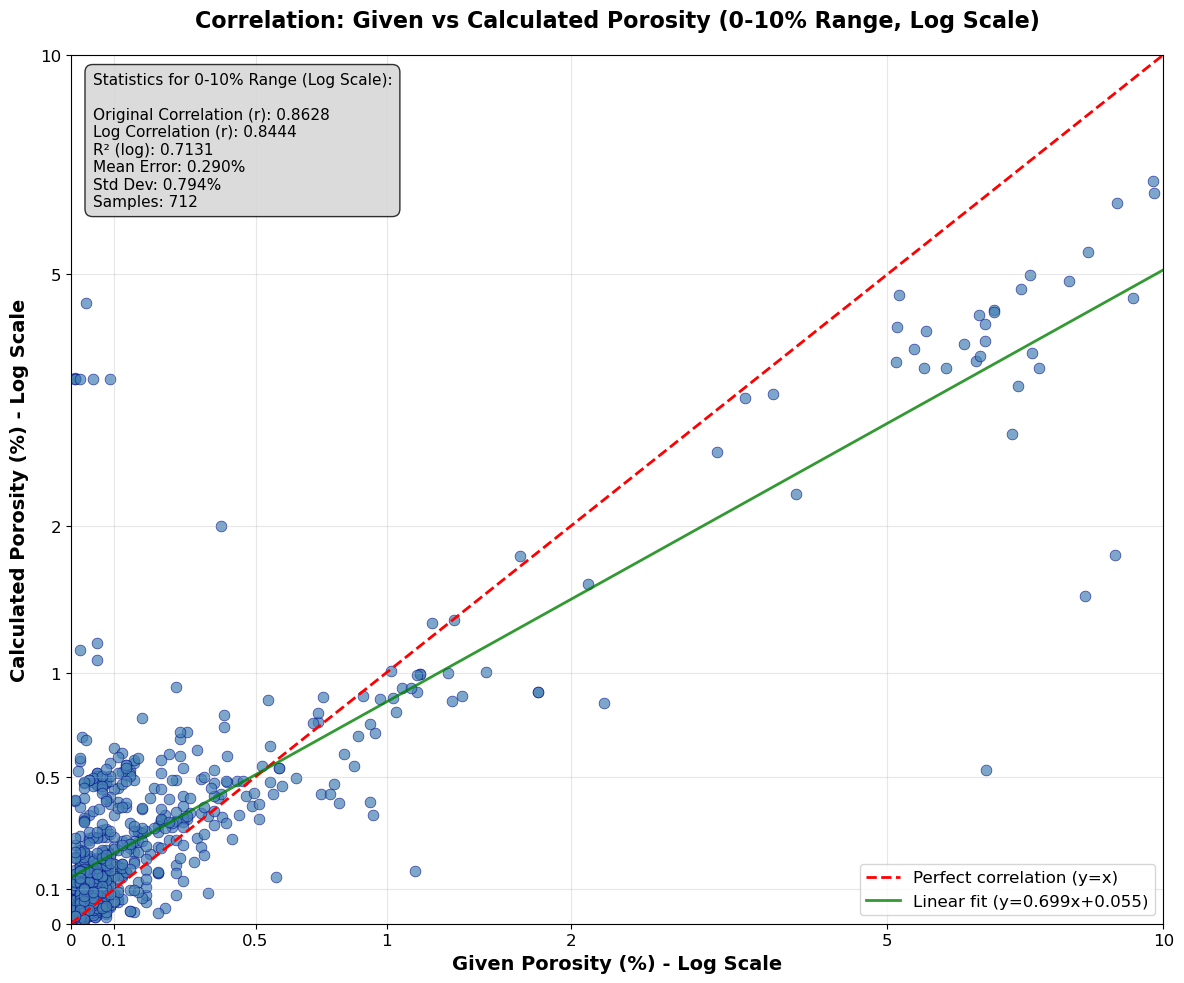

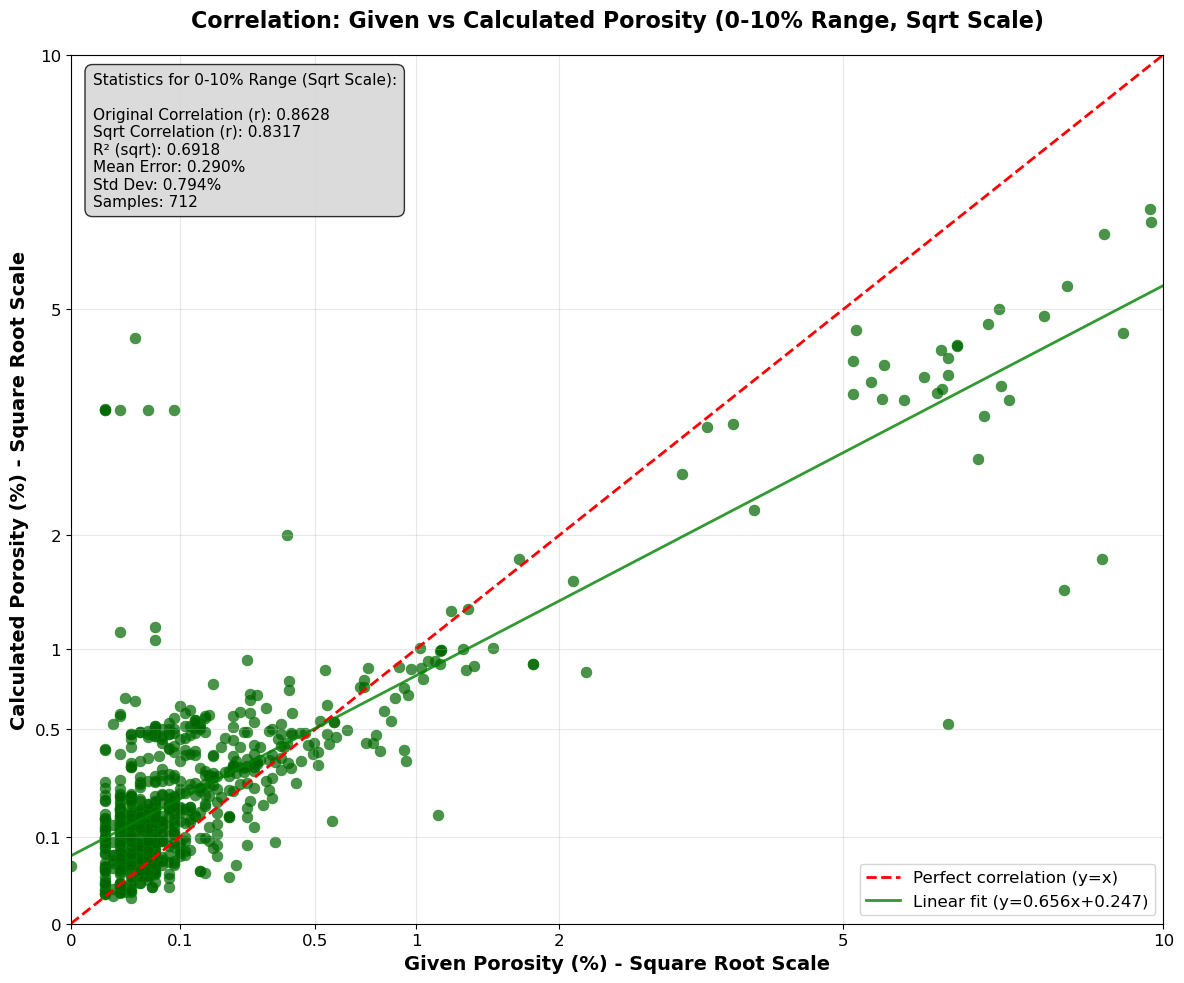


LOW POROSITY RANGE (0-10%) STATISTICS
Number of specimens: 712
Mean given porosity: 0.4642%
Mean calculated porosity: 0.4535%
Original correlation coefficient (r): 0.8628
Log-transformed correlation coefficient (r): 0.8444
Sqrt-transformed correlation coefficient (r): 0.8317
R-squared (original): 0.7445
R-squared (log): 0.7131
R-squared (sqrt): 0.6918
Mean absolute difference: 0.2902%
Median absolute difference: 0.0933%
Standard deviation of differences: 0.7940%
Maximum difference: 7.1365%
Minimum difference: 0.0001%

SPECIMENS IN 0-10% POROSITY RANGE
               name  porosity  calculated_porosity  difference  abs_difference
40       RE-C015-S9      0.29               0.3362      0.0462          0.0462
82     RE-B154-S001      1.68               1.7581      0.0781          0.0781
123    RE-B541-S6_1      0.03               0.2005      0.1705          0.1705
162    RE-B151_S005      9.76               6.7580     -3.0020          3.0020
163     RE-B447-S01      0.09               0.

In [77]:
# Filter data for 0-10% porosity range
low_porosity_df = comparison_df[
    (comparison_df['porosity'] <= 10) & 
    (comparison_df['calculated_porosity'] <= 10) &
    (comparison_df['porosity'] >= 0) & 
    (comparison_df['calculated_porosity'] >= 0)
].copy()

print(f"Filtered data: {len(low_porosity_df)} specimens in 0-10% porosity range")

if len(low_porosity_df) > 0:
    # Calculate statistics for low porosity range
    low_stats = {
        'mean_given': low_porosity_df['porosity'].mean(),
        'mean_calculated': low_porosity_df['calculated_porosity'].mean(),
        'mean_abs_diff': low_porosity_df['abs_difference'].mean(),
        'std_diff': low_porosity_df['difference'].std(),
        'correlation': low_porosity_df['porosity'].corr(low_porosity_df['calculated_porosity']),
        'median_abs_diff': low_porosity_df['abs_difference'].median(),
        'max_diff': low_porosity_df['abs_difference'].max(),
        'min_diff': low_porosity_df['abs_difference'].min(),
        'r_squared': low_porosity_df['porosity'].corr(low_porosity_df['calculated_porosity'])**2
    }
    
    # Create correlation plot with logarithmic transformation
    plt.figure(figsize=(12, 10))
    
    # Transform data using log(x+1) to handle zero values
    import numpy as np
    log_given = np.log10(low_porosity_df['porosity'] + 1)
    log_calculated = np.log10(low_porosity_df['calculated_porosity'] + 1)
    
    # Main scatter plot with log-transformed data
    plt.scatter(log_given, log_calculated, 
                alpha=0.7, s=60, color='steelblue', edgecolors='darkblue', linewidth=0.5)
    
    # Perfect correlation line in log space
    log_range = np.log10(np.array([0, 10]) + 1)
    plt.plot(log_range, log_range, 'r--', linewidth=2, label='Perfect correlation (y=x)')
    
    # Linear regression line in log space
    z_log = np.polyfit(log_given, log_calculated, 1)
    p_log = np.poly1d(z_log)
    plt.plot(log_range, p_log(log_range), 'g-', linewidth=2, alpha=0.8, 
             label=f'Linear fit (y={z_log[0]:.3f}x+{z_log[1]:.3f})')
    
    # Create custom tick labels for original porosity values
    tick_positions = np.log10(np.array([0, 0.1, 0.5, 1, 2, 5, 10]) + 1)
    tick_labels = ['0', '0.1', '0.5', '1', '2', '5', '10']
    
    # Formatting
    plt.xlim(log_range[0], log_range[1])
    plt.ylim(log_range[0], log_range[1])
    plt.xticks(tick_positions, tick_labels)
    plt.yticks(tick_positions, tick_labels)
    plt.xlabel('Given Porosity (%) - Log Scale', fontsize=14, fontweight='bold')
    plt.ylabel('Calculated Porosity (%) - Log Scale', fontsize=14, fontweight='bold')
    plt.title('Correlation: Given vs Calculated Porosity (0-10% Range, Log Scale)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Calculate correlation for log-transformed data
    log_correlation = np.corrcoef(log_given, log_calculated)[0,1]
    
    # Add statistics text box
    stats_text = f"""Statistics for 0-10% Range (Log Scale):
    
Original Correlation (r): {low_stats['correlation']:.4f}
Log Correlation (r): {log_correlation:.4f}
R² (log): {log_correlation**2:.4f}
Mean Error: {low_stats['mean_abs_diff']:.3f}%
Std Dev: {low_stats['std_diff']:.3f}%
Samples: {len(low_porosity_df)}"""
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(f'low_porosity_correlation_log_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Alternative: Square root transformation (less aggressive than log)
    plt.figure(figsize=(12, 10))
    
    # Transform data using square root
    sqrt_given = np.sqrt(low_porosity_df['porosity'])
    sqrt_calculated = np.sqrt(low_porosity_df['calculated_porosity'])
    
    # Main scatter plot with sqrt-transformed data
    plt.scatter(sqrt_given, sqrt_calculated, 
                alpha=0.7, s=60, color='darkgreen', edgecolors='green', linewidth=0.5)
    
    # Perfect correlation line in sqrt space
    sqrt_range = np.sqrt(np.array([0, 10]))
    plt.plot(sqrt_range, sqrt_range, 'r--', linewidth=2, label='Perfect correlation (y=x)')
    
    # Linear regression line in sqrt space
    z_sqrt = np.polyfit(sqrt_given, sqrt_calculated, 1)
    p_sqrt = np.poly1d(z_sqrt)
    plt.plot(sqrt_range, p_sqrt(sqrt_range), 'g-', linewidth=2, alpha=0.8, 
             label=f'Linear fit (y={z_sqrt[0]:.3f}x+{z_sqrt[1]:.3f})')
    
    # Create custom tick labels for original porosity values
    tick_positions_sqrt = np.sqrt(np.array([0, 0.1, 0.5, 1, 2, 5, 10]))
    tick_labels_sqrt = ['0', '0.1', '0.5', '1', '2', '5', '10']
    
    # Formatting
    plt.xlim(sqrt_range[0], sqrt_range[1])
    plt.ylim(sqrt_range[0], sqrt_range[1])
    plt.xticks(tick_positions_sqrt, tick_labels_sqrt)
    plt.yticks(tick_positions_sqrt, tick_labels_sqrt)
    plt.xlabel('Given Porosity (%) - Square Root Scale', fontsize=14, fontweight='bold')
    plt.ylabel('Calculated Porosity (%) - Square Root Scale', fontsize=14, fontweight='bold')
    plt.title('Correlation: Given vs Calculated Porosity (0-10% Range, Sqrt Scale)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Calculate correlation for sqrt-transformed data
    sqrt_correlation = np.corrcoef(sqrt_given, sqrt_calculated)[0,1]
    
    # Add statistics text box
    stats_text_sqrt = f"""Statistics for 0-10% Range (Sqrt Scale):
    
Original Correlation (r): {low_stats['correlation']:.4f}
Sqrt Correlation (r): {sqrt_correlation:.4f}
R² (sqrt): {sqrt_correlation**2:.4f}
Mean Error: {low_stats['mean_abs_diff']:.3f}%
Std Dev: {low_stats['std_diff']:.3f}%
Samples: {len(low_porosity_df)}"""
    
    plt.text(0.02, 0.98, stats_text_sqrt, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(f'low_porosity_correlation_sqrt_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed statistics for low porosity range
    print(f"\n{'='*80}")
    print("LOW POROSITY RANGE (0-10%) STATISTICS")
    print(f"{'='*80}")
    print(f"Number of specimens: {len(low_porosity_df)}")
    print(f"Mean given porosity: {low_stats['mean_given']:.4f}%")
    print(f"Mean calculated porosity: {low_stats['mean_calculated']:.4f}%")
    print(f"Original correlation coefficient (r): {low_stats['correlation']:.4f}")
    print(f"Log-transformed correlation coefficient (r): {log_correlation:.4f}")
    print(f"Sqrt-transformed correlation coefficient (r): {sqrt_correlation:.4f}")
    print(f"R-squared (original): {low_stats['r_squared']:.4f}")
    print(f"R-squared (log): {log_correlation**2:.4f}")
    print(f"R-squared (sqrt): {sqrt_correlation**2:.4f}")
    print(f"Mean absolute difference: {low_stats['mean_abs_diff']:.4f}%")
    print(f"Median absolute difference: {low_stats['median_abs_diff']:.4f}%")
    print(f"Standard deviation of differences: {low_stats['std_diff']:.4f}%")
    print(f"Maximum difference: {low_stats['max_diff']:.4f}%")
    print(f"Minimum difference: {low_stats['min_diff']:.4f}%")
    
    # Show specimens in low porosity range
    print(f"\n{'='*80}")
    print("SPECIMENS IN 0-10% POROSITY RANGE")
    print(f"{'='*80}")
    print(low_porosity_df[['name', 'porosity', 'calculated_porosity', 'difference', 'abs_difference']].round(4))
    
    # Save low porosity data
    low_porosity_df.to_csv(f'low_porosity_comparison_{timestamp}.csv', index=False)
    print(f"\nSaved low porosity data to: low_porosity_comparison_{timestamp}.csv")
    
else:
    print("No specimens found in the 0-10% porosity range")

In [ ]:
# sort comparison_df by absolute difference descending and show top rows
comparison_df = comparison_df.sort_values(by='abs_difference', ascending=False).reset_index(drop=True)
comparison_df.head(20)

,name,number,porosity,calculated_porosity,filename,difference,abs_difference,percent_difference
40,RE-C015-S9,S009,0.29,0.336214,RE-C015-S9.bmp,0.046214,0.046214,15.94
82,RE-B154-S001,S001,1.68,1.758104,RE-B154-S001.bmp,0.078104,0.078104,4.65
123,RE-B541-S6_1,S006,0.03,0.200469,RE-B541-S6_1.jpg,0.170469,0.170469,568.23
162,RE-B151_S005,S005,9.76,6.757994,RE-B151_S005.bmp,-3.002006,3.002006,-30.76
163,RE-B447-S01,S001,0.09,0.201066,RE-B447-S01.bmp,0.111066,0.111066,123.41
...,...,...,...,...,...,...,...,...
35405,RE-A012-S3,S003,0.30,0.412906,RE-A012-S3.bmp,0.112906,0.112906,37.64
35407,RE-B760_1,S001,0.12,0.241552,RE-B760_1.jpg,0.121552,0.121552,101.29
35408,RE-B797_4,S004,0.02,0.134072,RE-B797_4.jpg,0.114072,0.114072,570.36
35409,RE-A012-S7,S007,0.12,0.381160,RE-A012-S7.bmp,0.261160,0.261160,217.63


In [79]:
comparison_df = comparison_df.sort_values(by='abs_difference', ascending=False).reset_index(drop=True)
comparison_df.head(20)

,name,number,porosity,calculated_porosity,filename,difference,abs_difference,percent_difference
0,RE-C670_S001,S001,59.000,0.837925,RE-C670_S001.bmp,-58.162075,58.162075,-98.58
1,RE-B013,S001,34.150,6.469708,RE-B013.bmp,-27.680292,27.680292,-81.06
2,RE-B502_S005,S005,17.360,2.595885,RE-B502_S005.bmp,-14.764115,14.764115,-85.05
3,RE-B502_S003,S003,14.000,2.608799,RE-B502_S003.bmp,-11.391201,11.391201,-81.37
4,RE-B502_S002,S002,12.060,2.301381,RE-B502_S002.bmp,-9.758619,9.758619,-80.92
5,RE-A413-S07,S007,15.790,6.937959,RE-A413-S07.bmp,-8.852041,8.852041,-56.06
6,RE-B502_S004,S004,8.900,1.763548,RE-B502_S004.bmp,-7.136452,7.136452,-80.18
7,RE-B151_S002,S002,13.680,6.739710,RE-B151_S002.bmp,-6.940290,6.940290,-50.73
8,RE-B502_S001,S001,8.270,1.472281,RE-B502_S001.bmp,-6.797719,6.797719,-82.20
9,RE-B106-S02_1,S002,6.450,0.526561,RE-B106-S02_1.jpg,-5.923439,5.923439,-91.84


In [81]:
comparison_df.sort_values(by='porosity', ascending=True).head(20)

,name,number,porosity,calculated_porosity,filename,difference,abs_difference,percent_difference
501,RE-C484_S002,S002,0.00,0.044647,RE-C484_S002.bmp,0.044647,0.044647,inf
296,RE-C524_S029_1,S029,0.01,0.124906,RE-C524_S029_1.bmp,0.114906,0.114906,1149.06
235,RE-B091-S12,S012,0.01,0.158571,RE-B091-S12.bmp,0.148571,0.148571,1485.71
686,RE-B119_S001_1,S001,0.01,0.014796,RE-B119_S001_1.bmp,0.004796,0.004796,47.96
683,RE-B109_S001_1,S001,0.01,0.015334,RE-B109_S001_1.bmp,0.005334,0.005334,53.34
559,RE-B524_9,S002,0.01,0.041480,RE-B524_9.jpg,0.031480,0.031480,314.80
641,RE-B493-S003,S003,0.01,0.024306,RE-B493-S003.bmp,0.014306,0.014306,143.06
196,RE-B246-S002,S002,0.01,0.198678,RE-B246-S002.bmp,0.188678,0.188678,1886.78
374,RE-B157_S002_1,S002,0.01,0.099624,RE-B157_S002_1.bmp,0.089624,0.089624,896.24
376,RE-B139_S002_1,S002,0.01,0.099205,RE-B139_S002_1.bmp,0.089205,0.089205,892.05
